# Exploratory Data Analysis (EDA)

## Objective

The objective of this analysis is to understand demand patterns, inventory behavior, regional performance, pricing dynamics, promotional effectiveness, and other business factors that influence demand across the supply chain.

## Dataset Overview

### Key Observations

- The dataset contains 76,000 records spanning from January 2022 to January 2024.
- Groceries represent the largest product category in the dataset.
- The North region contributes the highest number of observations.
- Cloudy and Sunny weather conditions occur most frequently.
- Seasonal distribution is relatively balanced across all four seasons.
- Approximately 33% of records involve promotional activities.
- Around 20% of observations fall within epidemic periods.

These observations provide initial context for understanding demand behavior and supply chain performance.

In [2]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv('../Data/demand_forecasting.csv')

In [4]:
(df['Units Ordered']==0).sum()

(df['Units Ordered']==0).mean()*100

np.float64(61.98289473684211)

In [9]:
df['Date'] = pd.to_datetime(df['Date'])

In [10]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month Name'] = df['Date'].dt.month_name()
df['Quarter'] = df['Date'].dt.quarter
df['Day'] = df['Date'].dt.day
df['Day of Week'] = df['Date'].dt.day_name()
df['Week'] = df['Date'].dt.isocalendar().week

In [11]:
df['Weekend'] = df['Day of Week'].isin(['Saturday', 'Sunday'])

In [12]:
df['Inventory Coverage'] = df['Inventory Level'] / df['Demand']

In [13]:
df['Price Difference'] = df['Price'] - df['Competitor Pricing']

In [14]:
df['Discount Amount'] = df['Price'] * df['Discount'] / 100

In [15]:
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand,Year,Month,Month Name,Quarter,Day,Day of Week,Week,Weekend,Inventory Coverage,Price Difference,Discount Amount
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115,2022,1,January,1,1,Saturday,52,True,1.695652,-13.01,3.636
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229,2022,1,January,1,1,Saturday,52,True,0.510917,-11.86,12.024
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157,2022,1,January,1,1,Saturday,52,True,1.573248,2.86,6.294
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52,2022,1,January,1,1,Saturday,52,True,2.673077,2.44,8.763
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59,2022,1,January,1,1,Saturday,52,True,2.576271,2.78,0.000


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 27 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                76000 non-null  datetime64[us]
 1   Store ID            76000 non-null  str           
 2   Product ID          76000 non-null  str           
 3   Category            76000 non-null  str           
 4   Region              76000 non-null  str           
 5   Inventory Level     76000 non-null  int64         
 6   Units Sold          76000 non-null  int64         
 7   Units Ordered       76000 non-null  int64         
 8   Price               76000 non-null  float64       
 9   Discount            76000 non-null  int64         
 10  Weather Condition   76000 non-null  str           
 11  Promotion           76000 non-null  int64         
 12  Competitor Pricing  76000 non-null  float64       
 13  Seasonality         76000 non-null  str           
 14  E

In [53]:
df['Weekend'] = df['Weekend'].astype(int)

In [55]:
df.to_csv('../data/clean_supply_chain.csv', index=False)

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

pd.set_option('display.max_columns', None)

df = pd.read_csv('../data/cleaned_supply_chain.csv')

df['Date'] = pd.to_datetime(df['Date'])

In [20]:
print(df.shape)

(76000, 27)


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 27 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                76000 non-null  datetime64[us]
 1   Store ID            76000 non-null  str           
 2   Product ID          76000 non-null  str           
 3   Category            76000 non-null  str           
 4   Region              76000 non-null  str           
 5   Inventory Level     76000 non-null  int64         
 6   Units Sold          76000 non-null  int64         
 7   Units Ordered       76000 non-null  int64         
 8   Price               76000 non-null  float64       
 9   Discount            76000 non-null  int64         
 10  Weather Condition   76000 non-null  str           
 11  Promotion           76000 non-null  int64         
 12  Competitor Pricing  76000 non-null  float64       
 13  Seasonality         76000 non-null  str           
 14  E

In [22]:
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand,Year,Month,Month Name,Quarter,Day,Day of Week,Week,Weekend,Inventory Coverage,Price Difference,Discount Amount
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115,2022,1,January,1,1,Saturday,52,True,1.695652,-13.01,3.636
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229,2022,1,January,1,1,Saturday,52,True,0.510917,-11.86,12.024
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157,2022,1,January,1,1,Saturday,52,True,1.573248,2.86,6.294
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52,2022,1,January,1,1,Saturday,52,True,2.673077,2.44,8.763
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59,2022,1,January,1,1,Saturday,52,True,2.576271,2.78,0.000


In [23]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,76000,2023-01-15 12:00:00,2022-01-01 00:00:00,2022-07-09 18:00:00,2023-01-15 12:00:00,2023-07-24 06:00:00,2024-01-30 00:00:00,NaN
Inventory Level,76000.0,301.062842,0.0,136.0,227.0,408.0,2267.0,226.510161
Units Sold,76000.0,88.827316,0.0,58.0,84.0,114.0,426.0,43.994525
Units Ordered,76000.0,89.090645,0.0,0.0,0.0,121.0,1616.0,162.404627
Price,76000.0,67.726028,4.74,31.9975,64.5,95.83,228.03,39.377899
Discount,76000.0,9.087039,0.0,5.0,10.0,10.0,25.0,7.475781
Promotion,76000.0,0.328947,0.0,0.0,0.0,1.0,1.0,0.469834
Competitor Pricing,76000.0,69.454029,4.29,32.62,65.7,97.9325,261.22,40.943818
Epidemic,76000.0,0.2,0.0,0.0,0.0,0.0,1.0,0.400003
Demand,76000.0,104.317158,4.0,71.0,100.0,133.0,430.0,46.964801


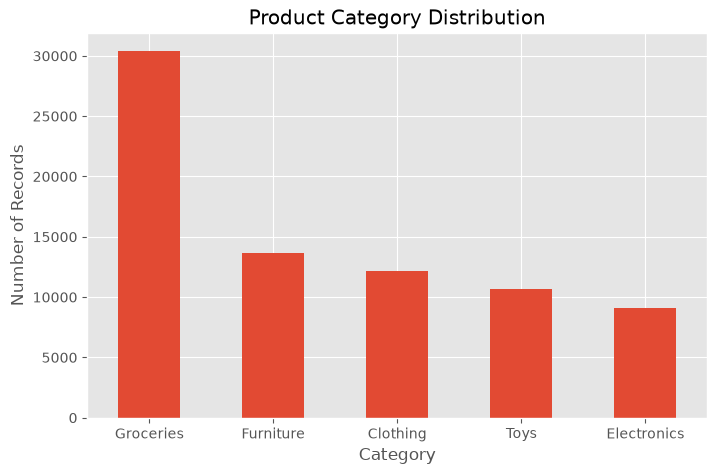

In [24]:
category_counts = df['Category'].value_counts()

plt.figure(figsize=(8,5))

category_counts.plot(kind='bar')

plt.title('Product Category Distribution')
plt.xlabel('Category')
plt.ylabel('Number of Records')

plt.xticks(rotation=0)

plt.show()

### Business Insight

- Groceries account for the largest proportion of records in the dataset.
- Electronics have the smallest representation.
- This suggests that grocery products experience higher transaction frequency and therefore require closer inventory monitoring.

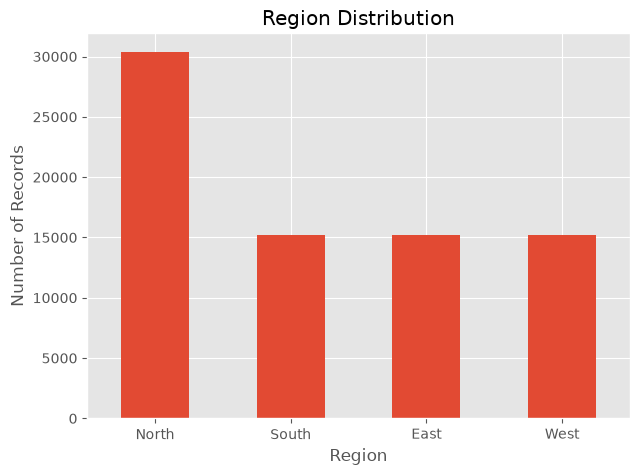

In [25]:
region_counts = df['Region'].value_counts()

plt.figure(figsize=(7,5))

region_counts.plot(kind='bar')

plt.title('Region Distribution')
plt.xlabel('Region')
plt.ylabel('Number of Records')

plt.xticks(rotation=0)

plt.show()

### Business Insight

- The North region contains approximately 40% of all observations.
- This indicates a larger operational footprint compared to the remaining regions.
- Inventory planning for the North region should therefore receive greater analytical focus.

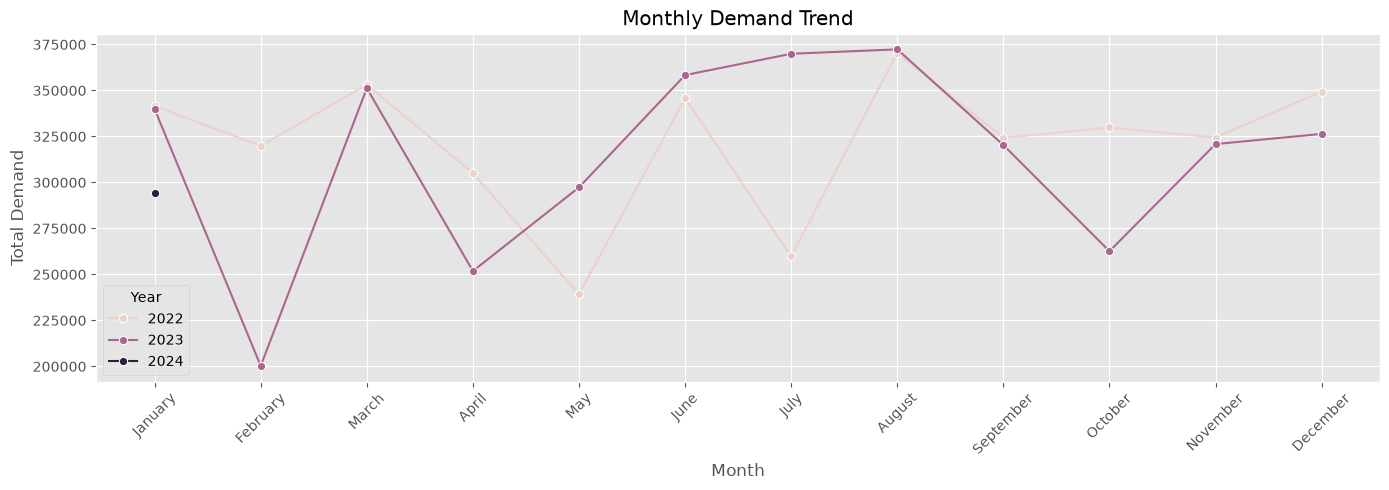

In [26]:
monthly_demand = (
    df.groupby(['Year', 'Month Name'])['Demand']
      .sum()
      .reset_index()
)

# Month order
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

monthly_demand['Month Name'] = pd.Categorical(
    monthly_demand['Month Name'],
    categories=month_order,
    ordered=True
)

monthly_demand = monthly_demand.sort_values(['Year','Month Name'])

plt.figure(figsize=(14,5))

sns.lineplot(
    data=monthly_demand,
    x='Month Name',
    y='Demand',
    hue='Year',
    marker='o'
)

plt.title("Monthly Demand Trend")
plt.xlabel("Month")
plt.ylabel("Total Demand")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Business Insight

- The visualization highlights monthly demand patterns across different years.
- It helps identify peak-demand months and seasonal fluctuations.
- Such trends are valuable for inventory planning and forecasting future demand.

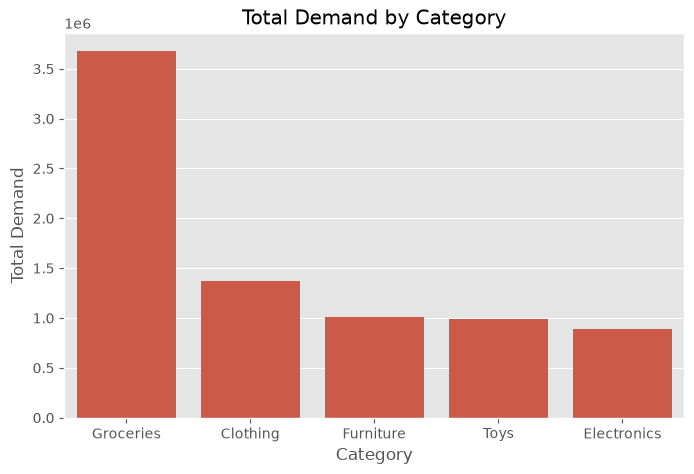

In [27]:
category_demand = (
    df.groupby('Category')['Demand']
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=category_demand.index,
    y=category_demand.values
)

plt.title("Total Demand by Category")
plt.xlabel("Category")
plt.ylabel("Total Demand")

plt.show()

### Business Insight

- This analysis identifies the product categories contributing the highest demand.
- High-demand categories require better inventory allocation and forecasting strategies.

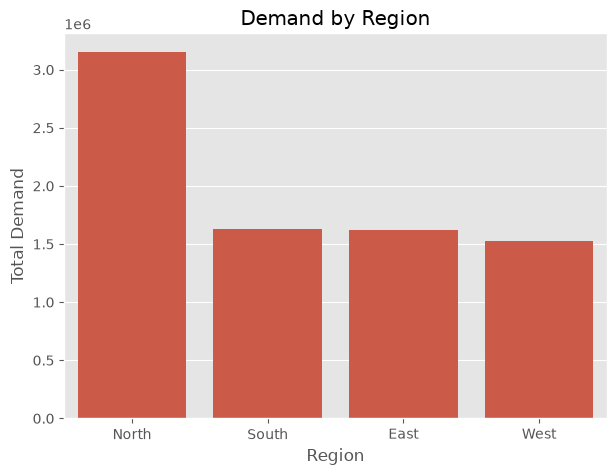

In [28]:
region_demand = (
    df.groupby('Region')['Demand']
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(7,5))

sns.barplot(
    x=region_demand.index,
    y=region_demand.values
)

plt.title("Demand by Region")
plt.xlabel("Region")
plt.ylabel("Total Demand")

plt.show()

### Business Insight

- Comparing regional demand helps identify high-performing markets.
- These insights support regional inventory allocation and supply chain optimization.

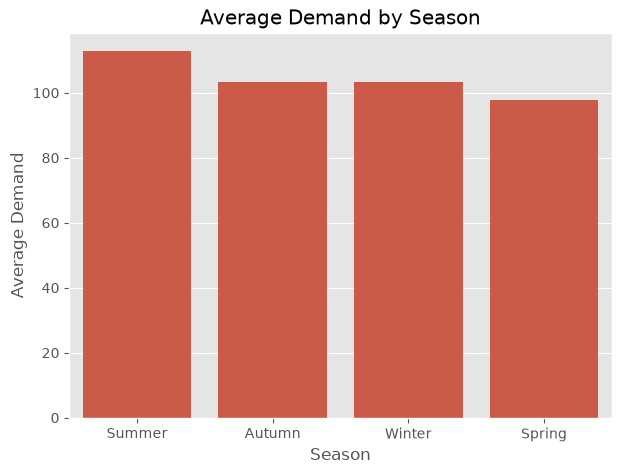

In [30]:
season_demand = (
    df.groupby('Seasonality')['Demand']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(7,5))

sns.barplot(
    x=season_demand.index,
    y=season_demand.values
)

plt.title("Average Demand by Season")
plt.xlabel("Season")
plt.ylabel("Average Demand")

plt.show()

### Business Insight

- Seasonal demand patterns provide valuable information for inventory planning.
- Understanding peak-demand seasons enables proactive stock replenishment and improved customer service.

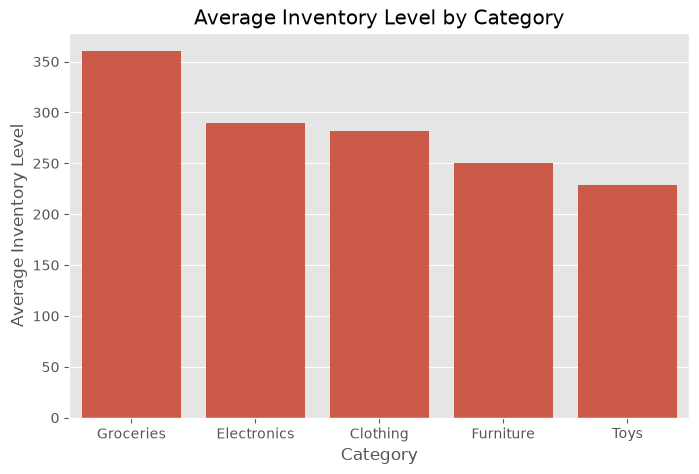

In [31]:
inventory_category = (
    df.groupby('Category')['Inventory Level']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=inventory_category.index,
    y=inventory_category.values
)

plt.title("Average Inventory Level by Category")
plt.xlabel("Category")
plt.ylabel("Average Inventory Level")

plt.show()

### Business Insight

This visualization compares the average inventory maintained across product categories and helps identify categories that require larger storage capacity.

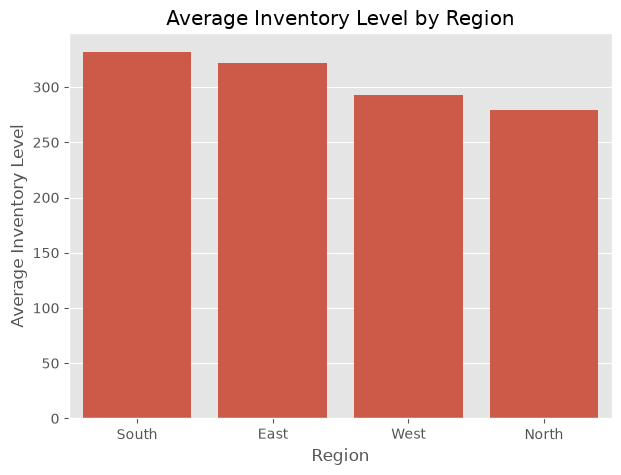

In [32]:
inventory_region = (
    df.groupby('Region')['Inventory Level']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(7,5))

sns.barplot(
    x=inventory_region.index,
    y=inventory_region.values
)

plt.title("Average Inventory Level by Region")
plt.xlabel("Region")
plt.ylabel("Average Inventory Level")

plt.show()

In [33]:
df['Stockout Risk'] = np.where(
    df['Inventory Level'] < df['Demand'],
    'High Risk',
    'Low Risk'
)

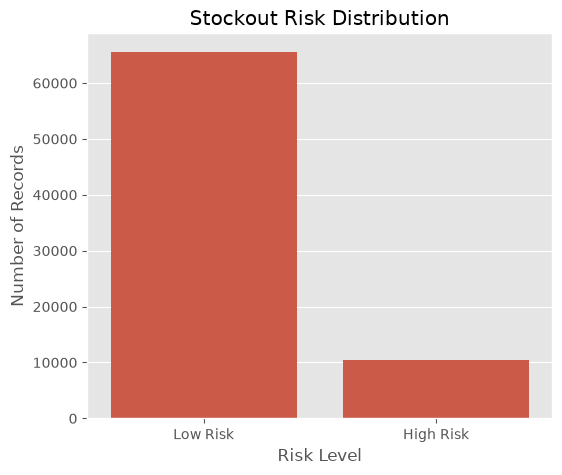

In [34]:
stockout = df['Stockout Risk'].value_counts()

plt.figure(figsize=(6,5))

sns.barplot(
    x=stockout.index,
    y=stockout.values
)

plt.title("Stockout Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Records")

plt.show()

### Business Insight

Products with inventory levels below demand are classified as high stockout risk. Identifying these products helps improve replenishment planning and minimize lost sales.

In [35]:
df['Overstock Risk'] = np.where(
    df['Inventory Level'] > (df['Demand']*2),
    'High Risk',
    'Normal'
)

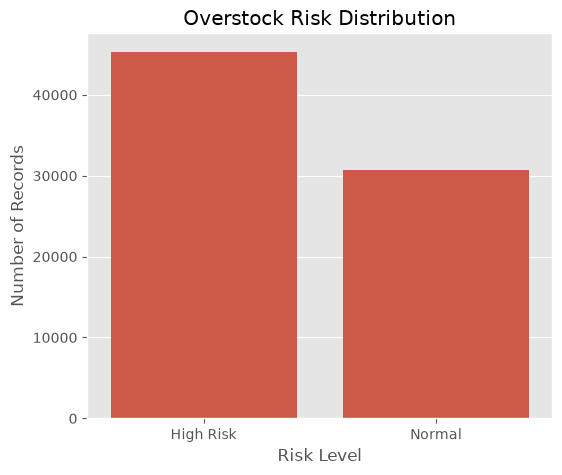

In [36]:
overstock = df['Overstock Risk'].value_counts()

plt.figure(figsize=(6,5))

sns.barplot(
    x=overstock.index,
    y=overstock.values
)

plt.title("Overstock Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Records")

plt.show()

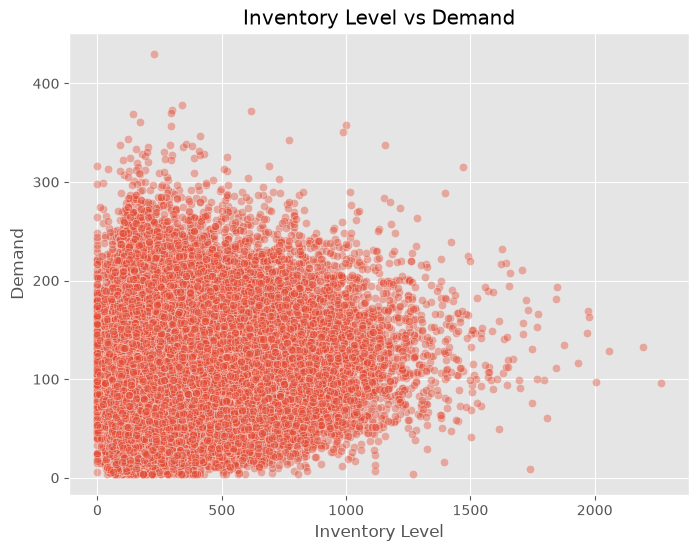

In [37]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Inventory Level',
    y='Demand',
    alpha=0.4
)

plt.title("Inventory Level vs Demand")
plt.xlabel("Inventory Level")
plt.ylabel("Demand")

plt.show()

### Business Insight

This analysis evaluates whether inventory levels increase proportionally with demand. Significant deviations may indicate inefficient inventory allocation.

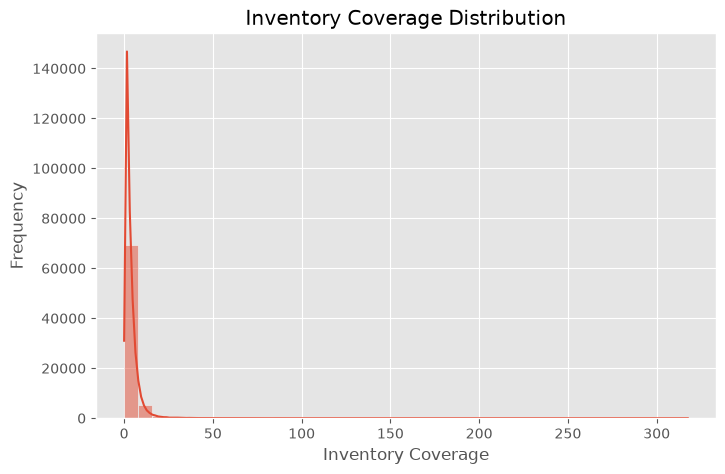

In [38]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Inventory Coverage'],
    bins=40,
    kde=True
)

plt.title("Inventory Coverage Distribution")
plt.xlabel("Inventory Coverage")
plt.ylabel("Frequency")

plt.show()

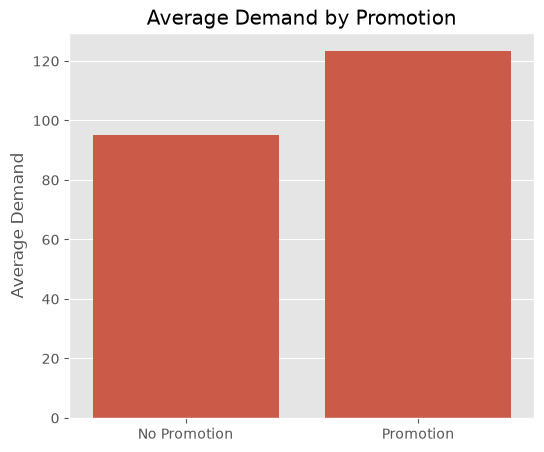

In [39]:
promotion_demand = (
    df.groupby('Promotion')['Demand']
      .mean()
      .reset_index()
)

promotion_demand['Promotion'] = promotion_demand['Promotion'].map({
    0:'No Promotion',
    1:'Promotion'
})

plt.figure(figsize=(6,5))

sns.barplot(
    data=promotion_demand,
    x='Promotion',
    y='Demand'
)

plt.title("Average Demand by Promotion")
plt.xlabel("")
plt.ylabel("Average Demand")

plt.show()

### Business Insight

This analysis evaluates whether promotional campaigns are associated with higher average customer demand compared to non-promotional periods.

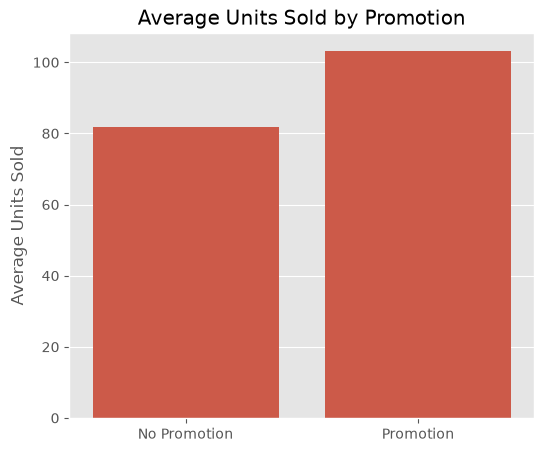

In [40]:
promotion_sales = (
    df.groupby('Promotion')['Units Sold']
      .mean()
      .reset_index()
)

promotion_sales['Promotion'] = promotion_sales['Promotion'].map({
    0:'No Promotion',
    1:'Promotion'
})

plt.figure(figsize=(6,5))

sns.barplot(
    data=promotion_sales,
    x='Promotion',
    y='Units Sold'
)

plt.title("Average Units Sold by Promotion")
plt.xlabel("")
plt.ylabel("Average Units Sold")

plt.show()

In [45]:
promotion_summary = (
    df.groupby('Promotion')[['Demand', 'Units Sold']]
      .mean()
      .round(2)
)

promotion_summary

,Demand,Units Sold
Promotion,,
0,95.03,81.83
1,123.27,103.10


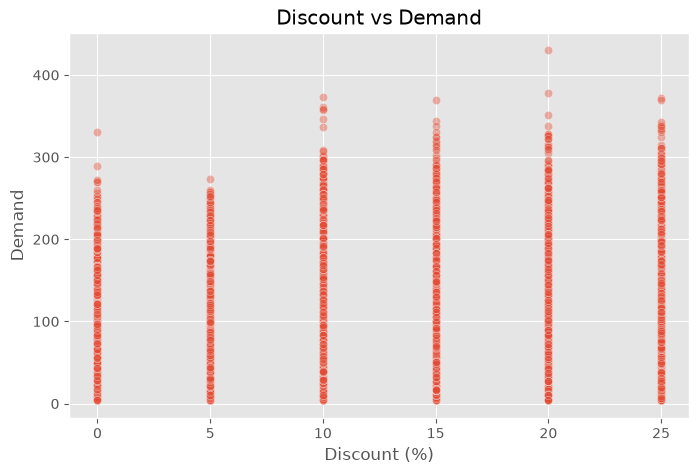

In [41]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Discount',
    y='Demand',
    alpha=0.4
)

plt.title("Discount vs Demand")
plt.xlabel("Discount (%)")
plt.ylabel("Demand")

plt.show()

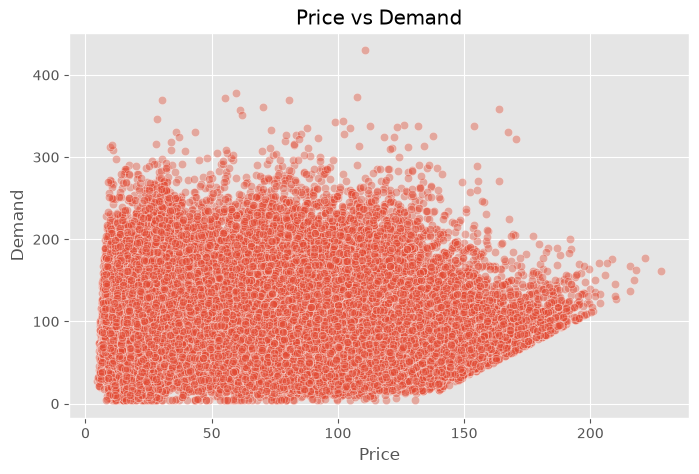

In [42]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Price',
    y='Demand',
    alpha=0.4
)

plt.title("Price vs Demand")
plt.xlabel("Price")
plt.ylabel("Demand")

plt.show()

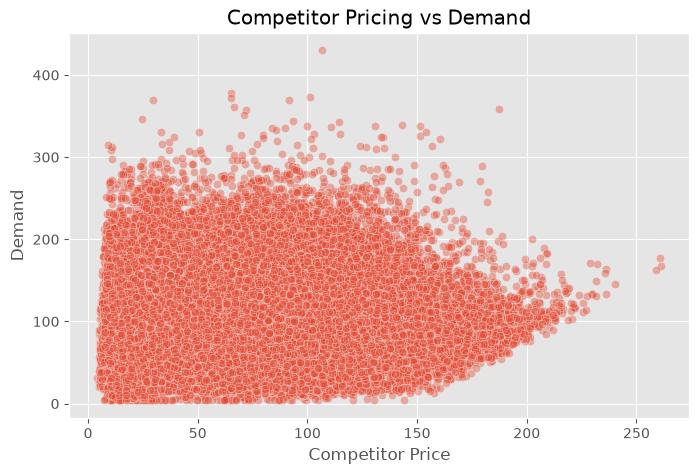

In [43]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Competitor Pricing',
    y='Demand',
    alpha=0.4
)

plt.title("Competitor Pricing vs Demand")
plt.xlabel("Competitor Price")
plt.ylabel("Demand")

plt.show()

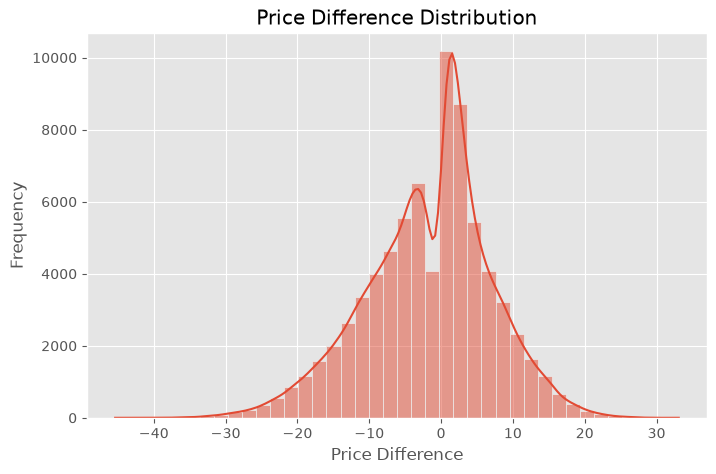

In [44]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Price Difference'],
    bins=40,
    kde=True
)

plt.title("Price Difference Distribution")
plt.xlabel("Price Difference")
plt.ylabel("Frequency")

plt.show()

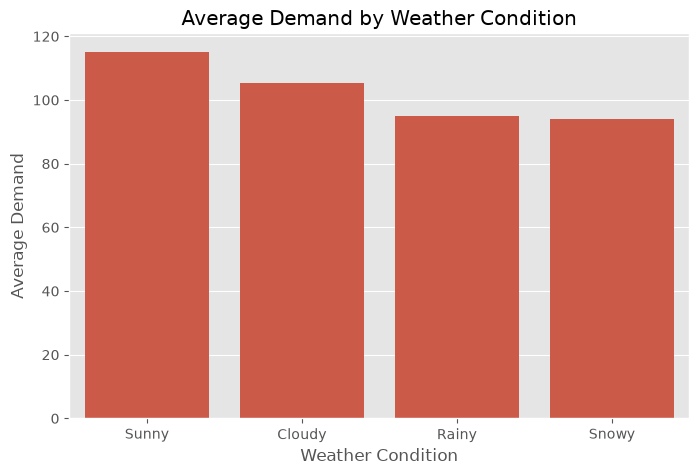

In [46]:
weather_demand = (
    df.groupby('Weather Condition')['Demand']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=weather_demand.index,
    y=weather_demand.values
)

plt.title("Average Demand by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Average Demand")

plt.show()

### Business Insight

This visualization helps identify whether weather conditions have a measurable impact on customer demand, enabling better inventory planning during different weather scenarios.

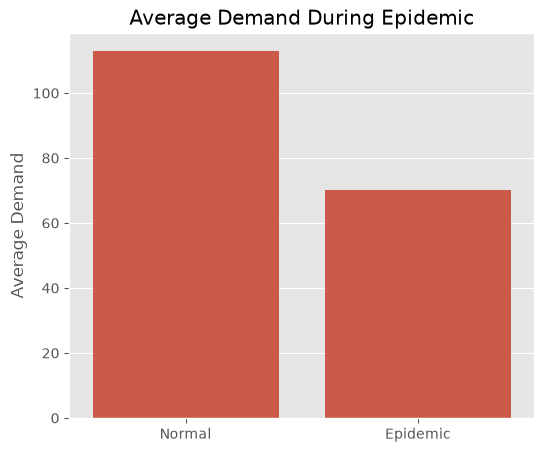

In [47]:
epidemic_demand = (
    df.groupby('Epidemic')['Demand']
      .mean()
      .reset_index()
)

epidemic_demand['Epidemic'] = epidemic_demand['Epidemic'].map({
    0:'Normal',
    1:'Epidemic'
})

plt.figure(figsize=(6,5))

sns.barplot(
    data=epidemic_demand,
    x='Epidemic',
    y='Demand'
)

plt.title("Average Demand During Epidemic")
plt.ylabel("Average Demand")
plt.xlabel("")

plt.show()

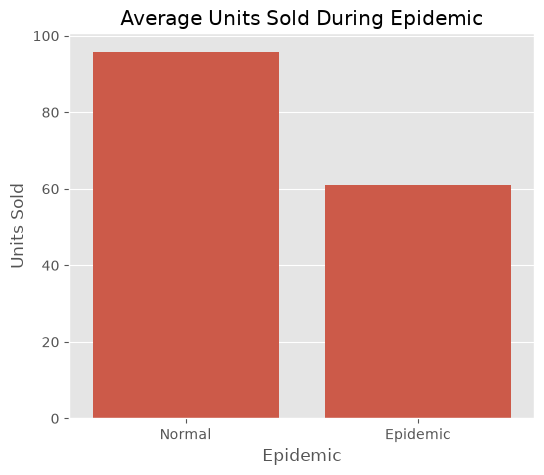

In [48]:
epidemic_sales = (
    df.groupby('Epidemic')['Units Sold']
      .mean()
      .reset_index()
)

epidemic_sales['Epidemic'] = epidemic_sales['Epidemic'].map({
    0:'Normal',
    1:'Epidemic'
})

plt.figure(figsize=(6,5))

sns.barplot(
    data=epidemic_sales,
    x='Epidemic',
    y='Units Sold'
)

plt.title("Average Units Sold During Epidemic")

plt.show()

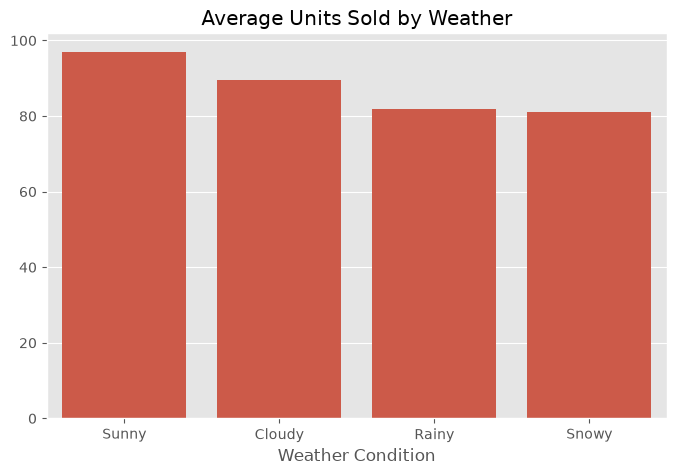

In [49]:
weather_sales = (
    df.groupby('Weather Condition')['Units Sold']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=weather_sales.index,
    y=weather_sales.values
)

plt.title("Average Units Sold by Weather")

plt.show()

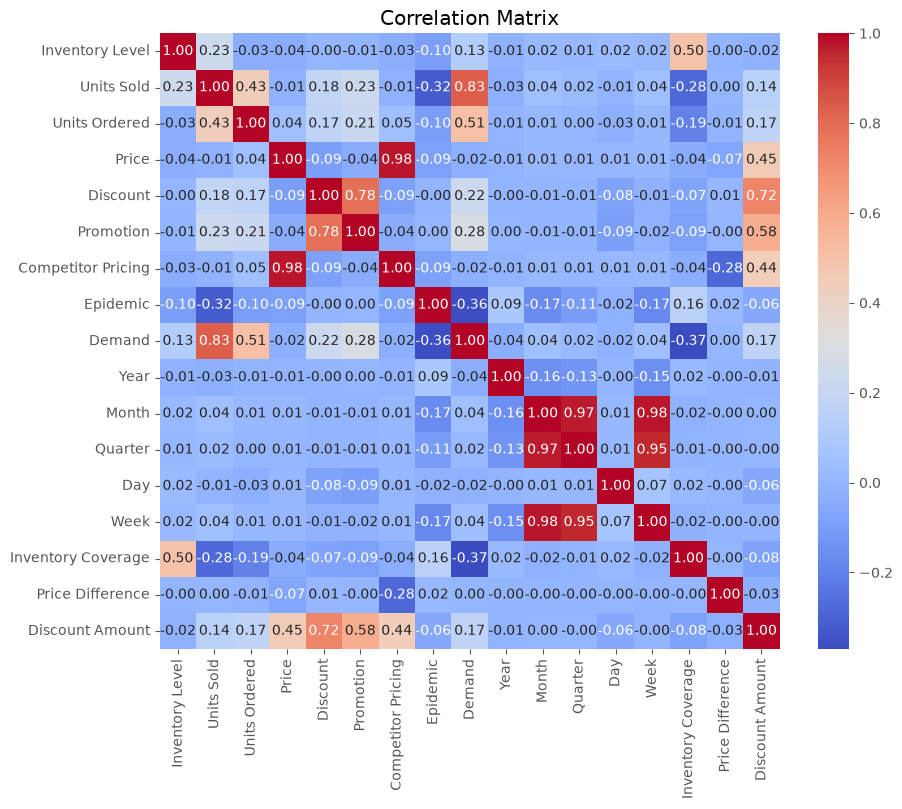

In [50]:
plt.figure(figsize=(10,8))

corr = df.select_dtypes(include=['number']).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix")

plt.show()

In [51]:
corr['Demand'].sort_values(ascending=False)

Demand                1.000000
Units Sold            0.833421
Units Ordered         0.511963
Promotion             0.282537
Discount              0.224723
Discount Amount       0.171832
Inventory Level       0.126618
Month                 0.042436
Week                  0.041136
Quarter               0.018874
Price Difference      0.002196
Day                  -0.018369
Competitor Pricing   -0.023036
Price                -0.023461
Year                 -0.036278
Epidemic             -0.363661
Inventory Coverage   -0.370983
Name: Demand, dtype: float64

### Business Insight

This analysis identifies the numerical variables most strongly associated with customer demand, helping prioritize features for demand forecasting models.

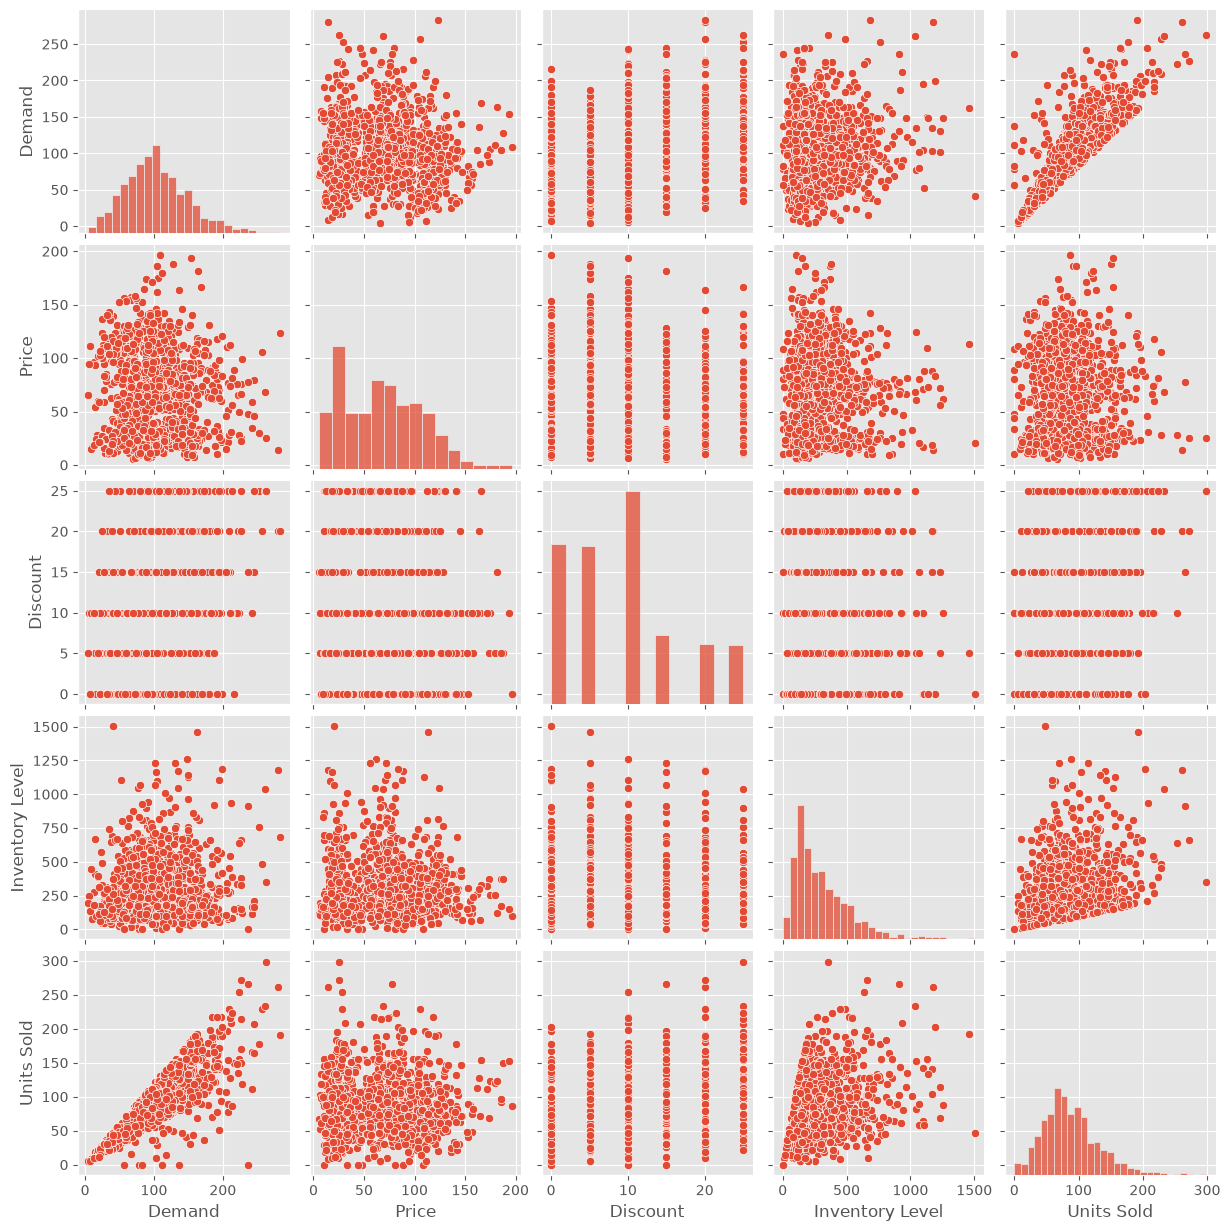

In [52]:
sample_df = df.sample(1000, random_state=42)

sns.pairplot(
    sample_df[['Demand',
               'Price',
               'Discount',
               'Inventory Level',
               'Units Sold']]
)

plt.show()

# Business Summary

## Key Findings

1. Highest demand category:
2. Highest demand region:
3. Strongest seasonal trend:
4. Impact of promotions:
5. Impact of discounts:
6. Inventory observations:
7. Weather influence:
8. Epidemic impact:
9. Strongest feature affecting demand:
10. Recommendations